# PFDA Project: E-Commerce & Consumer Behaviour

## **PART 1: INTRODUCTION & SETUP**

According to [IBM](https://www.ibm.com/think/topics/customer-analytics), customer analytics is about using customer data to understand what people want. This information guides everything a company does, from marketing to product updates, to making customers' experiences better. By improving these interactions, companies can attract more customers, increase sales, and build loyalty.

Customer analytics are important to help companies making smarter, faster decisions by understanding their customers' habits and needs. Using data like purchase history and feedback, businesses can see what is working, personalise their marketing, and focus on keeping their best customers. This leads to better products, more effective advertising, and happier customers, which helps companies becoming more profitable.

### **Data Source:**

This dataset contains detailed consumer behavior data, including purchasing habits, demographics, and preferences, making it ideal for market research, segmentation, and predictive analysis.

**Main Features:**
* Customer Demographics, Purchase Behavior, Customer Loyalty, Feedback, Decision-Making and Influences on Purchase.

Source: [Customer Shopping Trends Dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset)

### Why was this chosen? 

This dataset is the perfect foundation for my project, aligning directly with my academic focus and general interest. With a BSc in Marketing and an MSc in Digital Marketing — in which I specialised in strategy — I feel compelled to translate data into a decision making tool and a competitive advantage. 

I am also fascinated by why people make the decisions they do. This file provides the material to answer behavioural questions, allows me to build predictive models and strategic insights that describe and anticipate behaviour.


#### Main research questions

**Customer Demographics & Profiling**

 - Who are the core customers in terms of age, gender, and spending power?

 - How does purchase behaviour vary by age group?

 - How does purchase behaviour differ by gender?

**Purchasing Habits & Drivers** 

 - What is the average purchase amount, frequency, and repeat buyer rate?

 - How does purchase intent influence spending?

 - Do discounts drive higher satisfaction or spending?

 - What are the most popular product categories overall and by segment?

**Channels & Payment Preferences**

 - Which devices drive the most engagement, especially with social media and ads?

 - Which payment methods perform best in terms of volume, revenue, and efficiency?

**Geographic & Loyalty Insights**

 - In which countries/markets is revenue concentrated, and where is brand loyalty strongest?
 - How loyal are customers overall, and how does loyalty program membership impact behavior?

**Temporal & Forecasting Questions**

 - Are there seasonal or monthly trends in purchases and spending?
 - Can we forecast future purchase growth?

**Marketing Strategy Questions**

 - What customer profile should we target for personalized marketing and ads?

 - How effective are current channels (social media, ads, mobile) for driving purchases?
 
 - Where should we allocate resources for growth (e.g., markets, payments, promotions)?

In [49]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os

# Visualisation libraries
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Scikit-learn for modeling
from sklearn.linear_model import LinearRegression

# Geolocation and date handling
import geonamescache as gc

# Machine learning library
from datetime import datetime


# Confirmation message
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. DATA ACQUISITION

### 1.1 Loading the Dataset

The dataset is provided as a CSV file and stored locally within the project directory.
This section loads the dataset into a pandas DataFrame and performs an initial check to confirm successful loading.

In [50]:
# Loading the CSV file
FILENAME = "Ecommerce_Consumer_Behavior_Analysis_Data.csv"
DATADIR = "data/"
FULLPATH = DATADIR + FILENAME

# Read the CSV file into a DataFrame with error handling
if os.path.exists(FULLPATH):
	df = pd.read_csv(FULLPATH, encoding='utf-8')
	print(f"Dataset shape: {df.shape}")
else:
	print(f"File not found: {FULLPATH}")
	print("Please check the file path and ensure the data directory exists")

# Display the first few rows of the DataFrame
display(df.head())


Dataset shape: (1000, 28)


,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


### 1.2 Initial Data Inspection

Initial inspection of the dataset is performed to understand its structure, including the number of observations, variable types, and the presence of missing values. 
This step helps identify any issues that need to be addressed before analysis and modelling.

In [51]:
# DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

The results show that the dataset contains a mix of numerical and categorical variables related to customer demographics, purchasing behaviour, and engagement.
Several variables contain missing values, which will be addressed during the data cleaning phase. 

### 2. DATA CLEANING

### 2.1 Handling Missing Values

Missing values can negatively impact both exploratory analysis and predictive modelling. In this project, numerical and categorical variables are handled separately using appropriate imputation strategies.

- Numerical variables are imputed using the median, as it is robust to outliers.
- Categorical variables are imputed using the most frequent value (mode).

In [52]:
# Select columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns # Numerical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns  # Categorical columns

# Missing values before imputation
print("Missing values after imputation :")
print(df.isnull().sum())

# Impute numerical columns using median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Impute categorical columns using mode
for col in cat_cols: 
    mode_val = df[col].mode()
    if not mode_val.empty:
        df[col] = df[col].fillna(mode_val[0])
    else:
        df[col] = df[col].fillna('Unknown')  # Or drop the column if fully missing

# Missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values after imputation :
Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method       

### 2.2 Outlier Detection

Outliers are observations that differ significantly from other values in the dataset and may arise from data entry errors, rare events, or natural variation.
If not addressed, outliers can skew statistical analysis and negatively impact machine learning models.

The Interquartile Range (IQR) method is used to identify potential outliers in numerical variables.

Source: [GeeksforGeeks](https://www.geeksforgeeks.org/data-science/detect-and-remove-the-outliers-using-python/)

Remove outliers using [IQR](https://www.geeksforgeeks.org/machine-learning/interquartile-range-to-detect-outliers-in-data/), for accuracy:



In [53]:
# Let's check if the data contains any outliers in numeric columns
# And we'll include the Purchase_Amount column in the analysis, as it's numeric now

# Detect outliers using the IQR method
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    outlier_summary[col] = outliers.shape[0]

# Display outlier counts
pd.Series(outlier_summary, name="Outlier_Count")

Age                                      0
Frequency_of_Purchase                    0
Brand_Loyalty                            0
Product_Rating                           0
Time_Spent_on_Product_Research(hours)    0
Return_Rate                              0
Customer_Satisfaction                    0
Time_to_Decision                         0
Name: Outlier_Count, dtype: int64

The results show that some numerical variables contain values classified as outliers using the IQR method. However, for variables such as purchase amount, these values may represent legitimate high-spending customers rather than erroneous data.

Therefore, outliers were identified but not removed at this stage, as they may carry meaningful business insights.

### 2.3 Date & Time Processing

* We'll also convert the date and time column into a fixed format

In [54]:
# Convert 'Time_of_Purchase' to datetime format
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
print("Converted 'Time_of_Purchase' to datetime format.")

Converted 'Time_of_Purchase' to datetime format.


The "Location" column seem to have too many different cities, which can be difficult to profile our customers. We'll group them bu countries, as it is  easier to manipulate the data, using geopy.geocoders (Nominatim)

Source: [GeeksforGeeks](https://www.geeksforgeeks.org/python/get-the-city-state-and-country-names-from-latitude-and-longitude-using-python/)

### 2.4 Age groups

And we'll create group ages, to simplify demographic analysis and improve the interpretation of customer segments.

In [55]:
# First create Age_Group from Age column
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Now, we'll check the age group distribution
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_counts.columns = ['Age_Group', 'Count']

age_group_counts

Age_Group
18-25    222
26-35    308
36-45    320
46-55    150
55+        0
Name: count, dtype: int64

#### 2.4.1 Refining Age Groups

After creating age groups, the distribution is reviewed to ensure that all categories contain observations -- Any unused age groups are removed to improve clarity in analysis and visualisation.


In [56]:
# Remove unused age group if present
if '55+' in age_group_counts.index and age_group_counts.loc['55+'] == 0:
    df['Age_Group'] = df['Age_Group'].cat.remove_categories(['55+'])
    age_group_counts = df['Age_Group'].value_counts().sort_index()

print("Age Group Distribution:")
print(age_group_counts)

Age Group Distribution:
Age_Group
18-25    222
26-35    308
36-45    320
46-55    150
Name: count, dtype: int64


**Standardising Country Names**

In [57]:
import geonamescache
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
from time import sleep

# --- Step 1: Offline mapping with geonamescache (instant, covers most major cities) ---
gc = geonamescache.GeonamesCache()
cities = gc.get_cities()  # Dictionary of city IDs to details
countries = gc.get_countries()  # Dictionary of country codes to details

# Build mapping: lowercase city name -> country name (English)
city_to_country = {}
for city_info in cities.values():
    name = city_info['name'].lower()
    country_code = city_info['countrycode']
    if country_code in countries:
        country_name = countries[country_code]['name']  # English name, e.g., "United States"
        city_to_country[name] = country_name

# Optional: Add common aliases/variants if needed (e.g., 'nyc' -> 'new york')
# city_to_country['nyc'] = 'United States'

# Create Country column
df['Country'] = df['Location'].str.lower().map(city_to_country)

print(f"Offline mapping covered: {df['Country'].notna().sum()} / {len(df)} rows")

Offline mapping covered: 386 / 1000 rows


In [58]:
'''

# --- Step 2: Nominatim fallback ONLY for unmatched ---
geolocator = Nominatim(user_agent="pfda_project_yourname")  # Use unique agent

def geocode_country(location):
    try:
        loc = geolocator.geocode(location, addressdetails=True, language='en', timeout=10)
        if loc and 'country' in loc.raw.get('address', {}):
            return loc.raw['address']['country']
        return "Unknown"
    except:
        return "Unknown"

# Use RateLimiter (handles delays + retries)
geocode = RateLimiter(geocode_country, min_delay_seconds=1.1, max_retries=3)  # Slight >1 for safety

# Only unique unmatched locations
unmatched_locs = df.loc[df['Country'].isna(), 'Location'].unique()
print(f"Geocoding fallback needed for {len(unmatched_locs)} unique locations...")

mapping_dict = {loc: geocode(loc) for loc in unmatched_locs}  # Dict comprehension with built-in delay

df.loc[df['Country'].isna(), 'Country'] = df['Location'].map(mapping_dict)

print("Final unknown countries:", df['Country'].eq("Unknown").sum())

'''

'\n\n# --- Step 2: Nominatim fallback ONLY for unmatched ---\ngeolocator = Nominatim(user_agent="pfda_project_yourname")  # Use unique agent\n\ndef geocode_country(location):\n    try:\n        loc = geolocator.geocode(location, addressdetails=True, language=\'en\', timeout=10)\n        if loc and \'country\' in loc.raw.get(\'address\', {}):\n            return loc.raw[\'address\'][\'country\']\n        return "Unknown"\n    except:\n        return "Unknown"\n\n# Use RateLimiter (handles delays + retries)\ngeocode = RateLimiter(geocode_country, min_delay_seconds=1.1, max_retries=3)  # Slight >1 for safety\n\n# Only unique unmatched locations\nunmatched_locs = df.loc[df[\'Country\'].isna(), \'Location\'].unique()\nprint(f"Geocoding fallback needed for {len(unmatched_locs)} unique locations...")\n\nmapping_dict = {loc: geocode(loc) for loc in unmatched_locs}  # Dict comprehension with built-in delay\n\ndf.loc[df[\'Country\'].isna(), \'Country\'] = df[\'Location\'].map(mapping_dict)\n\npr

In [59]:
'''

# Standardise country names using pycountry
import pycountry

def standard_country(name):
    if pd.isna(name) or name == "Unknown":
        return name
    
    # Handle special cases that pycountry doesn't recognize
    special_cases = {
        "Palestinian Territories": "Palestine, State of",
        "South Sudan": "South Sudan",
        "United States": "United States",
        "United Kingdom": "United Kingdom",
        "Russia": "Russian Federation",
        "South Korea": "Korea, Republic of",
        "North Korea": "Korea, Democratic People's Republic of",
        "Iran": "Iran, Islamic Republic of",
        "Syria": "Syrian Arab Republic",
        "Venezuela": "Venezuela, Bolivarian Republic of",
        "Bolivia": "Bolivia, Plurinational State of",
        "Taiwan": "Taiwan, Province of China",
        "Vatican": "Holy See (Vatican City State)"
    }
    
    # Check special cases first
    if name in special_cases:
        name = special_cases[name]
    
    # Direct lookup
    country = pycountry.countries.get(name=name)
    if country:
        return country.name  # Official English name
    
    # Fuzzy search for common variants
    try:
        matches = pycountry.countries.search_fuzzy(name)
        if matches:
            return matches[0].name
    except LookupError:
        # If fuzzy search fails, return original name
        pass
    
    return name  # Fallback to original

df["Country"] = df["Country"].apply(standard_country)

'''


'\n\n# Standardise country names using pycountry\nimport pycountry\n\ndef standard_country(name):\n    if pd.isna(name) or name == "Unknown":\n        return name\n    \n    # Handle special cases that pycountry doesn\'t recognize\n    special_cases = {\n        "Palestinian Territories": "Palestine, State of",\n        "South Sudan": "South Sudan",\n        "United States": "United States",\n        "United Kingdom": "United Kingdom",\n        "Russia": "Russian Federation",\n        "South Korea": "Korea, Republic of",\n        "North Korea": "Korea, Democratic People\'s Republic of",\n        "Iran": "Iran, Islamic Republic of",\n        "Syria": "Syrian Arab Republic",\n        "Venezuela": "Venezuela, Bolivarian Republic of",\n        "Bolivia": "Bolivia, Plurinational State of",\n        "Taiwan": "Taiwan, Province of China",\n        "Vatican": "Holy See (Vatican City State)"\n    }\n    \n    # Check special cases first\n    if name in special_cases:\n        name = special_cas

In [60]:
# Check if Purchase_Amount is object type (string), if so convert it
if df['Purchase_Amount'].dtype == 'object':
	df['Purchase_Amount'] = df['Purchase_Amount'].str.replace('$', '', regex=False).astype(float).round(2)
	
result = df.groupby('Gender')['Purchase_Amount'].mean()
print("Average Purchase Amount by Gender:")
print(result)

Average Purchase Amount by Gender:
Gender
Agender       243.78
Bigender      258.47
Female        282.09
Genderfluid   295.22
Genderqueer   279.52
Male          267.62
Non-binary    287.73
Polygender    308.11
Name: Purchase_Amount, dtype: float64


In [61]:
# Swapping any other gender that is not Female or Male into Other
df['Gender'] = df['Gender'].apply(lambda x: x if x in ['Female', 'Male'] else 'Other') # Standardising gender
print("Unique genders after grouping:", df['Gender'].unique())

Unique genders after grouping: ['Female' 'Male' 'Other']


The results show differences in average purchase amounts across genders. This suggests that purchasing behaviour may vary by gender, which could be leveraged for targeted marketing and personalised offers. However, further analysis is required to determine whether these differences are statistically significant.

### 2.6 Saving the Cleaned Dataset

The cleaned dataset is saved to a new CSV file to ensure it can be reproduced and allow us to use it again in later stages of the analysis without repeating data preparation.

In [62]:
# Saving cleaned data to a new CSV file  for easy access later
CLEAN_FILENAME = "Consumer_Behavior_Clean.csv"
CLEAN_FULLPATH = "data/" + CLEAN_FILENAME
df.to_csv(CLEAN_FULLPATH, index=False)

print(f"Cleaned data saved to: {CLEAN_FULLPATH}")

Cleaned data saved to: data/Consumer_Behavior_Clean.csv


## 3. Exploratory Data Analysis (EDA)

This section explores the cleaned dataset to identify patterns, trends, and relationships related to customer demographics and purchasing behaviour.

### 3.1 Numerical Feature Summary

Summary statistics are examined for numerical variables to understand central tendencies, variability, and potential anomalies in the data.

In [63]:
# Statistical summary of the DataFrame (taking into account only numerical columns)
pd.options.display.float_format = '{:.2f}'.format
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Age,1000.00,34.30,18.00,26.00,34.50,42.00,50.00,9.35
Purchase_Amount,1000.00,275.06,50.71,162.24,276.16,388.98,498.33,131.53
Frequency_of_Purchase,1000.00,6.95,2.00,4.00,7.00,10.00,12.00,3.15
Brand_Loyalty,1000.00,3.03,1.00,2.00,3.00,4.00,5.00,1.42
Product_Rating,1000.00,3.03,1.00,2.00,3.00,4.00,5.00,1.44
Time_Spent_on_Product_Research(hours),1000.00,1.01,0.00,0.00,1.00,2.00,2.00,0.79
Return_Rate,1000.00,0.95,0.00,0.00,1.00,2.00,2.00,0.81
Customer_Satisfaction,1000.00,5.40,1.00,3.00,5.00,8.00,10.00,2.87
Time_of_Purchase,1000,2024-06-29 06:31:40.800000,2024-01-01 00:00:00,2024-04-04 00:00:00,2024-06-30 00:00:00,2024-09-19 00:00:00,2024-12-30 00:00:00,NaN
Time_to_Decision,1000.00,7.55,1.00,4.00,8.00,11.00,14.00,4.04


#### Descriptive Analysis

* **Who are my customers?**

In [64]:
# What is the average age of customers?
average_age = df['Age'].mean()
print(f"The average age of customers is: {average_age:.2f} years")

The average age of customers is: 34.30 years


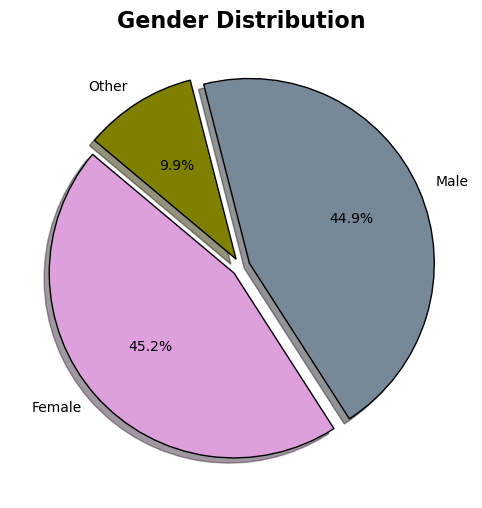

In [65]:
# Calculate gender distribution
gender_counts = df['Gender'].value_counts()

# Splittting the slices for better visibility
explode = [0.05] * len(gender_counts)

plt.figure(figsize=(12, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', explode=explode, colors=['plum', 'lightslategray', 'olive'],
        wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=140)
plt.title("Gender Distribution", fontsize=16, fontweight='bold')

plt.show()

The gender distribution illustrates the composition of the customer base, which is important for tailoring marketing messages and product offerings to different customer segments.

### 3.2 Purchase Behaviour by Age Group

In [66]:
# Average purchase amount by age group
age_group_perf = df.groupby('Age_Group', observed=False)['Purchase_Amount'].mean()

# Remove empty categories if present
age_group_perf = age_group_perf.dropna()
age_group_perf

Age_Group
18-25   279.03
26-35   277.99
36-45   274.92
46-55   263.49
Name: Purchase_Amount, dtype: float64

The average purchase amount varies across age groups, indicating differences in spending behaviour by age -- this can be useful for age-targeted marketing and product positioning.

### 3.3 Purchase Amount Distribution by Age Group

A boxplot is used to visualise the distribution of purchase amounts across age groups, highlighting differences in central tendency and variability.

In [67]:
# Define desired age group order
desired_order = ['18-25', '26-35', '36-45', '46-55']

# Keeping categories that exist in the data
existing_categories = [cat for cat in desired_order if cat in df['Age_Group'].cat.categories]

# Reorder categories safely with ordered=True
df['Age_Group'] = df['Age_Group'].cat.reorder_categories(existing_categories, ordered=True)

# Create the boxplot with proper ordering
fig = px.box(df, x='Age_Group', y='Purchase_Amount', 
             color='Age_Group', 
             title='Purchase Amount Distribution by Age Group',
             category_orders={'Age_Group': existing_categories})

fig.update_layout(width=1300, height=800)
fig.show()

Purchase amounts are visualised using a boxplot to compare the distribution, median, and variability across age groups.

The distribution shows that some age groups exhibit higher differences in purchase amounts, while others display more consistent spending behaviour.

### 3.4 Revenue Contribution by Product Category

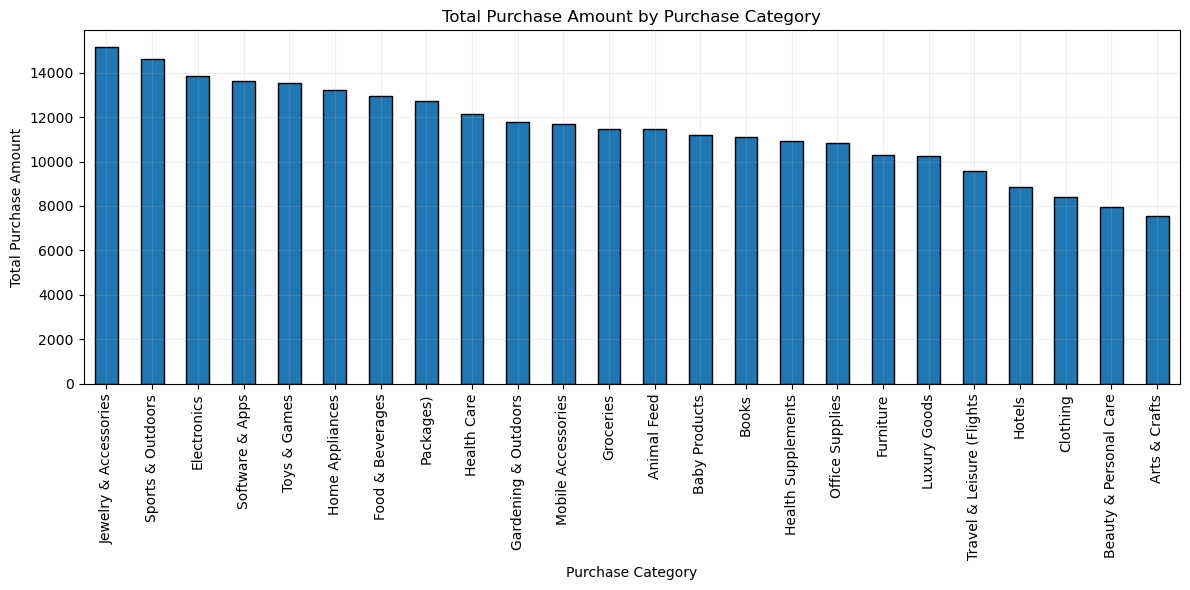

In [68]:
# Total revenue by purchase category
category_revenue = (df.groupby("Purchase_Category")["Purchase_Amount"].sum().sort_values(ascending=False))

# Formatting the plot
plt.figure(figsize=(12, 6))
category_revenue.plot(kind="bar", edgecolor="black")
plt.title("Total Purchase Amount by Purchase Category")
plt.ylabel("Total Purchase Amount")
plt.xlabel("Purchase Category")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The results show that revenue is concentrated in a small number of product categories -- this insight can inform inventory planning, marketing focus, and product strategy by prioritising high-revenue categories.

### 3.5 Age Group Frequency Distribution

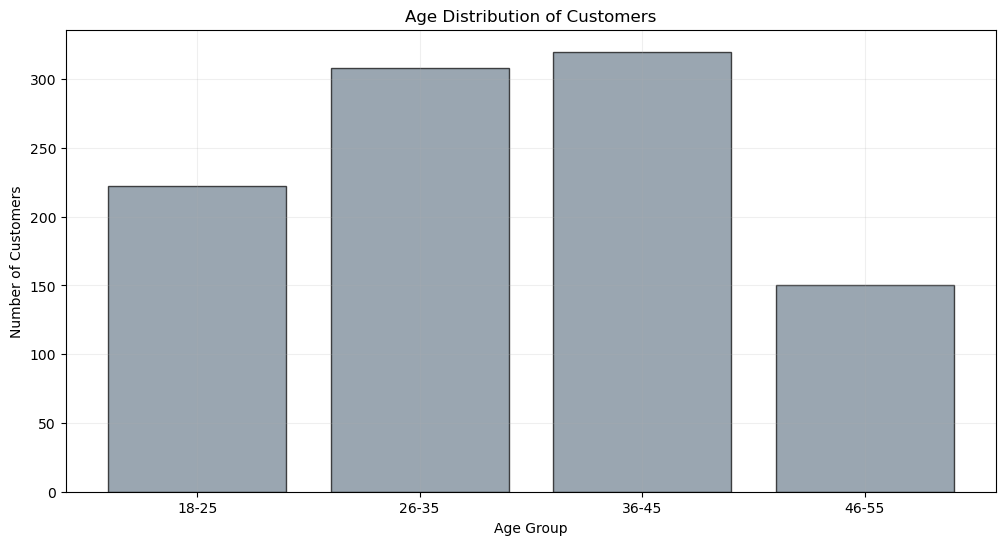

In [69]:
# Age group distribution
age_group_counts = df['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(age_group_counts.index, age_group_counts.values, color='slategray', edgecolor='black', alpha=0.7)
plt.title('Age Distribution of Customers')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)

plt.show()

Age distribution shows how customers are concentrated across different age groups, providing insight into the dominant demographic segments engaging with the platform.

### 3.6 Purchase Behaviour & Intent


This section examines how customer intent influences purchasing behaviour, with a focus on spending patterns and purchase value.

In [70]:
# Creating boxplots of Purchase Amount by Purchase Intent
fig = px.box(df, x='Purchase_Intent', y='Purchase_Amount', color='Purchase_Intent', title='Purchase Amount by Purchase Intent')
fig.update_layout(width=1200, height=600)
fig.update_traces(marker=dict(line=dict(width=0.5)))
fig.show()

The boxplot shows that purchase amount varies across different levels of
purchase intent. Higher intent levels are associated with higher median
spending and greater variability, suggesting that intent is a strong indicator
of purchase value.

In [71]:
# How do most customers pay?
payment_method_counts = df['Payment_Method'].value_counts()
payment_method_counts

Payment_Method
PayPal         219
Other          204
Debit Card     196
Credit Card    194
Cash           187
Name: count, dtype: int64

In [72]:
# In percentages, which gender is more likely to use discounts when making purchases?
discount_usage = df.groupby('Gender')['Discount_Used'].mean() * 100
discount_usage

Gender
Female   53.10
Male     50.33
Other    55.56
Name: Discount_Used, dtype: float64

The results show differences in discount usage across genders, indicating that some customer segments may be more responsive to promotional pricing strategies than others.

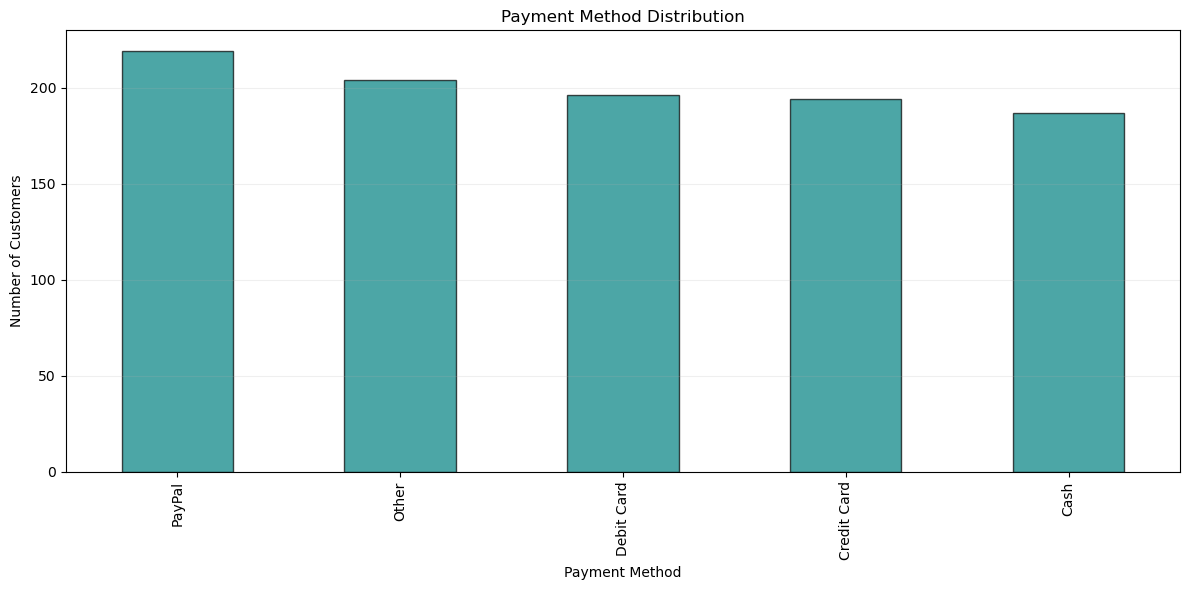

In [73]:
# Plotting the payment method distribution
plt.figure(figsize=(12, 6))
payment_method_counts.plot(kind='bar', edgecolor='black', color='teal', alpha=0.7)

# Formatting the plot
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()

plt.show()

The results show a clear preference for certain payment methods, indicating how customers most commonly complete transactions. Understanding these preferences can help optimise the checkout process and reduce friction at the point of sale.

### 3.7 Purchase Channel Preferences by Gender

In [74]:
# Which Shopping Channel is preferred by different Genders?
gender_channel_pct = (pd.crosstab(df['Gender'], df['Purchase_Channel'], normalize='index') * 100).round(2)

gender_channel_pct

Purchase_Channel,In-Store,Mixed,Online
Gender,,,
Female,31.86,34.07,34.07
Male,34.08,33.63,32.29
Other,29.29,35.35,35.35


The table shows differences in preferred purchase channels across genders -- the found patterns can guide channel-specific marketing strategies and platform optimisation.

### 3.8 Device Usage Patterns

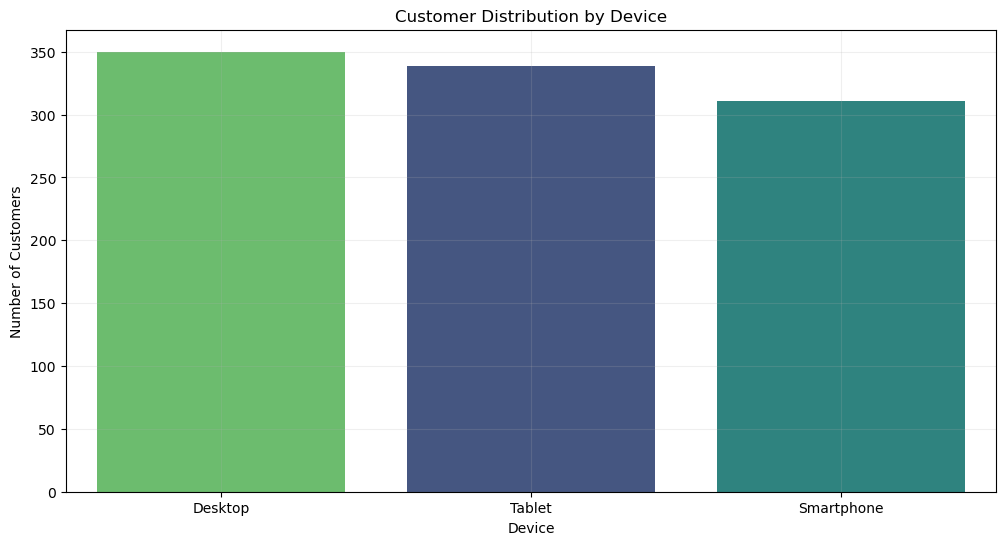

In [75]:
# What device do they access the platform from?
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Device_Used_for_Shopping', order=df['Device_Used_for_Shopping'].value_counts().index, palette='viridis', hue='Device_Used_for_Shopping')
plt.title('Customer Distribution by Device')
plt.xlabel('Device')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)
plt.show()

The results highlight the devices most commonly used by customers to access the platform and aid with decisions around platform optimisation and mobile-first strategies.

* **Social Media Influence by Age Group**

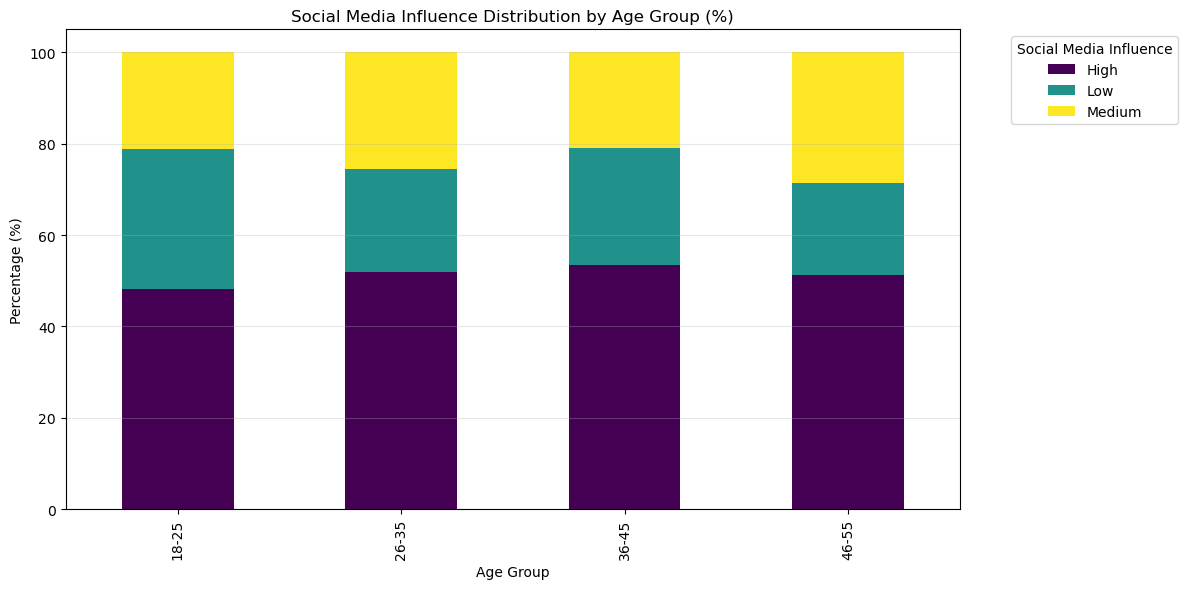

Social Media Influence by Age Group (%):
Social_Media_Influence  High   Low  Medium
Age_Group                                 
18-25                  48.20 30.63   21.17
26-35                  51.95 22.40   25.65
36-45                  53.44 25.62   20.94
46-55                  51.33 20.00   28.67


In [76]:
# Percentage of each influence level within each age group
age_social_influence = (pd.crosstab(df['Age_Group'], df['Social_Media_Influence'], normalize='index') * 100).round(2)

# Drop empty group if needed (e.g., '55+' has no data)
age_social_influence = age_social_influence.dropna()

# Stacked bar plot
age_social_influence.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Social Media Influence Distribution by Age Group (%)')
plt.xlabel('Age Group')
plt.ylabel('Percentage (%)')
plt.legend(title='Social Media Influence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print table for exact values
print("Social Media Influence by Age Group (%):")
print(age_social_influence)

* **Social Media Influence by Device**

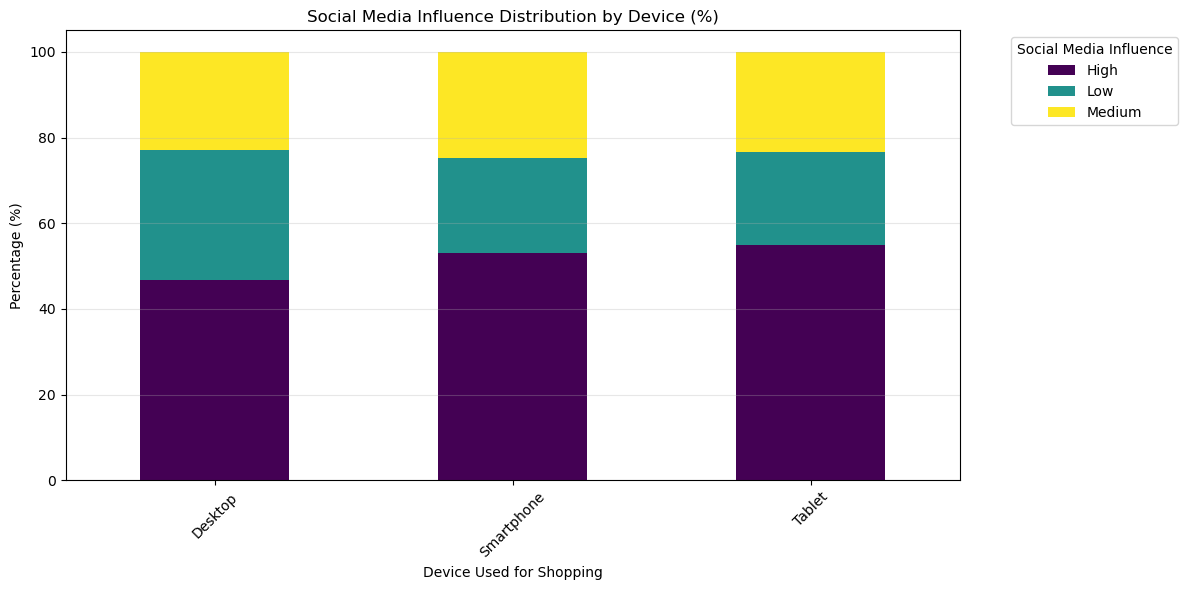

Social Media Influence by Device (%):
Social_Media_Influence    High   Low  Medium
Device_Used_for_Shopping                    
Desktop                  46.86 30.29   22.86
Smartphone               53.05 22.19   24.76
Tablet                   54.87 21.83   23.30


In [77]:
# PercentagCalculating the percentage of each influence level within each device
device_social_influence = (pd.crosstab(df['Device_Used_for_Shopping'], df['Social_Media_Influence'], normalize='index') * 100).round(2)

# Creating stacked bar plot
device_social_influence.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Social Media Influence Distribution by Device (%)')
plt.xlabel('Device Used for Shopping')
plt.ylabel('Percentage (%)')
plt.legend(title='Social Media Influence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Alternative: Print the table for exact values
print("Social Media Influence by Device (%):")
print(device_social_influence)

**Ad Engagement by Age Group**

In [78]:
# Age group performance: average spend and ad engagement rate
age_group_performance = (
    df.groupby('Age_Group', observed=False)
    .agg(Avg_Purchase_Amount=('Purchase_Amount', 'mean'),
         Ad_Engagement_Rate=('Engagement_with_Ads',
                            lambda x: (x == 'Yes').mean() * 100))
                            .round(2))

age_group_performance

,Avg_Purchase_Amount,Ad_Engagement_Rate
Age_Group,,
18-25,279.03,0.00
26-35,277.99,0.00
36-45,274.92,0.00
46-55,263.49,0.00


The results show that advertisement engagement varies across age groups. Differences in engagement rates, combined with variations in average purchase amounts, suggest that certain age segments may be more responsive to marketing campaigns than others.

### 3.9 Gender Performance and Ad Engagement

In [79]:
# Now, we'll group by genders and calculate the average purchase amount
# Gender performance with ad engagement rate
gender_perf = (df.groupby('Gender', observed=False).agg(Avg_Purchase_Amount=('Purchase_Amount', 'mean'),
                Ad_Engagement=('Engagement_with_Ads', lambda x: (x == 'Yes').count())).round(2))

gender_perf

,Avg_Purchase_Amount,Ad_Engagement
Gender,,
Female,282.09,452
Male,267.62,449
Other,276.76,99


The results show differences in both spending behaviour and engagement with advertising across genders.
Higher engagement numbers may indicate greater responsiveness to promotional campaigns.

### 3.10 Average Purchase Amount by Age Group

In [80]:
# We'll also look at age groups performance by averaging purchase amount
age_group_perf = df.groupby('Age_Group', observed=False)['Purchase_Amount'].mean()

age_group_perf


Age_Group
18-25   279.03
26-35   277.99
36-45   274.92
46-55   263.49
Name: Purchase_Amount, dtype: float64

Average spending differs across age groups, suggesting that age is an important factor in purchasing behaviour.

### 3.10 Geographic Distribution of Revenue

In [81]:
# Grouping by Country and sum Purchase_Amount
country_revenue = df.groupby("Country")["Purchase_Amount"].sum().sort_values(ascending=False).head(10)
display(country_revenue)


Country
China           9267.96
Brazil          9222.87
United States   8709.67
France          6396.56
Russia          5987.47
Japan           5675.33
Philippines     3766.51
Indonesia       3302.30
Iran            3237.64
Sweden          2880.31
Name: Purchase_Amount, dtype: float64

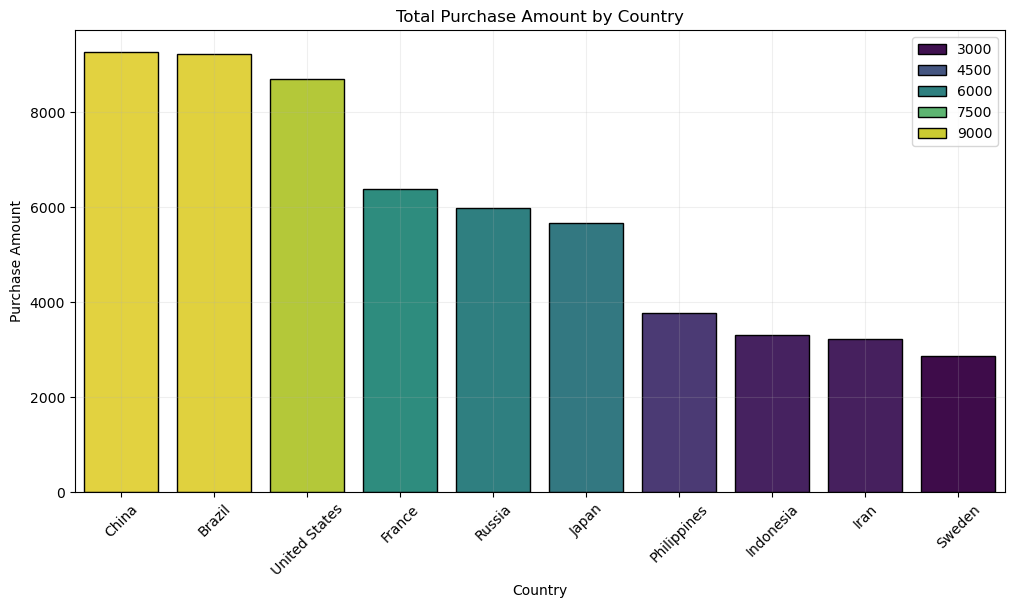

In [82]:
# Plotting the total purchase amount by country
plt.figure(figsize=(12, 6))
sns.barplot(x=country_revenue.index, y=country_revenue.values, palette='viridis', edgecolor='black', hue=country_revenue.values)

# Formatting the plot
plt.title("Total Purchase Amount by Country")
plt.ylabel("Purchase Amount")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.show()

Revenue is concentrated in a small number of countries, indicating key markets for the organisation.

The regions may represent priority regions for targeted marketing, localisation strategies, and future investment.

In [83]:
# Checking Brand Loyalty distribution in percentage
df['Brand_Loyalty'].value_counts(normalize=True, dropna=False) * 100




Brand_Loyalty
5   20.80
3   20.60
1   19.60
4   19.60
2   19.40
Name: proportion, dtype: float64

In [84]:
# Top 10 countries by total purchase amount
top_10_countries = country_revenue.head(10).index

# Average brand loyalty score by country (top 10 revenue countries)
top_10_loyalty = (df[df['Country'].isin(top_10_countries)].groupby('Country')['Brand_Loyalty']
    .mean().round(2).sort_values(ascending=False))

top_10_loyalty

Country
Indonesia       4.00
Iran            3.56
Brazil          3.38
Sweden          3.18
China           3.16
Philippines     3.00
France          2.84
Japan           2.81
United States   2.80
Russia          2.55
Name: Brand_Loyalty, dtype: float64

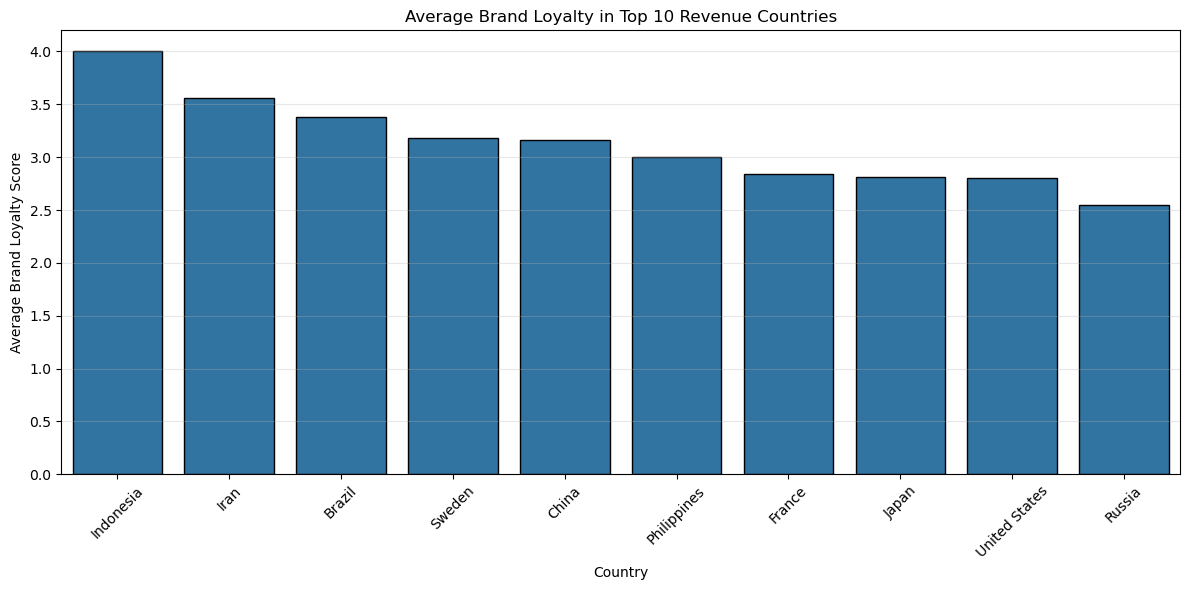

In [85]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_loyalty.index,
    y=top_10_loyalty.values,
    edgecolor='black'
)
plt.title("Average Brand Loyalty in Top 10 Revenue Countries")
plt.ylabel("Average Brand Loyalty Score")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The results indicate that brand loyalty varies across the organisation’s top revenue-generating countries. Some high-revenue markets also demonstrate strong customer loyalty, while others may rely more heavily on transactional purchases. These results can inform market-specific retention strategies.

* **What are they doing? (Behavioral)**

* How do they browse and buy? (Frequent browsers, cart abandoners, first-time vs. repeat buyers).

The boxplot shows that purchase amount varies across different levels of purchase intent. 
Higher intent levels are associated with higher median spending and greater variability, suggesting that intent is a strong indicator of purchase value.

### 3.11 Customer 

This section evaluates overall customer satisfaction and explores how satisfaction
varies across different customer segments and purchasing conditions. 

* What convinced them to buy?


In [86]:
# How many, in percentage terms, are members of our loyalty program?
loyalty_counts = df['Customer_Loyalty_Program_Member'].value_counts(normalize=True).round(4) * 100
loyalty_counts

Customer_Loyalty_Program_Member
False   50.90
True    49.10
Name: proportion, dtype: float64

**Satisfaction distribution**

In [87]:
# How many customers are highly satisfied (rating of 4 or more)?
highly_satisfied_counts = (df['Customer_Satisfaction'] >= 4).value_counts(normalize=True).round(3) * 100
highly_satisfied_counts

Customer_Satisfaction
True    68.50
False   31.50
Name: proportion, dtype: float64

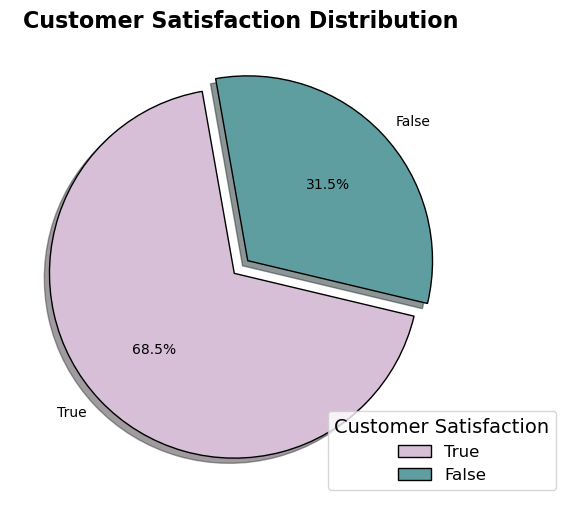

In [88]:
# And now for the big reveal, we'll plot the pie chart with nice colours and black edges to enhance visualisation
plt.figure(figsize=(12,6))
plt.pie(highly_satisfied_counts, labels=highly_satisfied_counts.index, autopct='%1.1f%%', colors=['thistle', 'cadetblue'],
        wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=100,
        explode=[0.05]*len(highly_satisfied_counts))

# We'll add 3D effect to the pie chart
plt.gca().set_aspect('equal')  # Ensures that pie is drawn as a circle
plt.title("Customer Satisfaction Distribution", fontsize=16, fontweight='bold')
plt.legend(title="Customer Satisfaction", fontsize=12, title_fontsize=14, loc='lower right', bbox_to_anchor=(1.2, 0))

plt.show()

# Source: https://matplotlib.org/stable/gallery/color/named_colors.html

The results indicate that a majority of customers report high satisfaction levels, suggesting that generally positive customer experiences, though further analysis is required to understand what factors contribute to satisfaction.

**Satisfaction by gender**

In [89]:
# Customer satisfaction by gender
fig = px.box(df, x='Gender', y='Customer_Satisfaction', title='Customer Satisfaction by Gender')
fig.update_layout(width=1000, height=500)

fig.show()

The boxplot suggests that customer satisfaction levels are fairly similar across genders, with only minor differences in median ratings; indicating that overall satisfaction is relatively consistent across all gender groups.

* What are their values, interests, or lifestyle? (Personality traits, tech adoption).
* How did they first hear about us? (Marketing channel effectiveness). **(Discount and advertising)**

### 3.12 Trends in Purchasing Behaviour

#### Monthly Revenue Trends

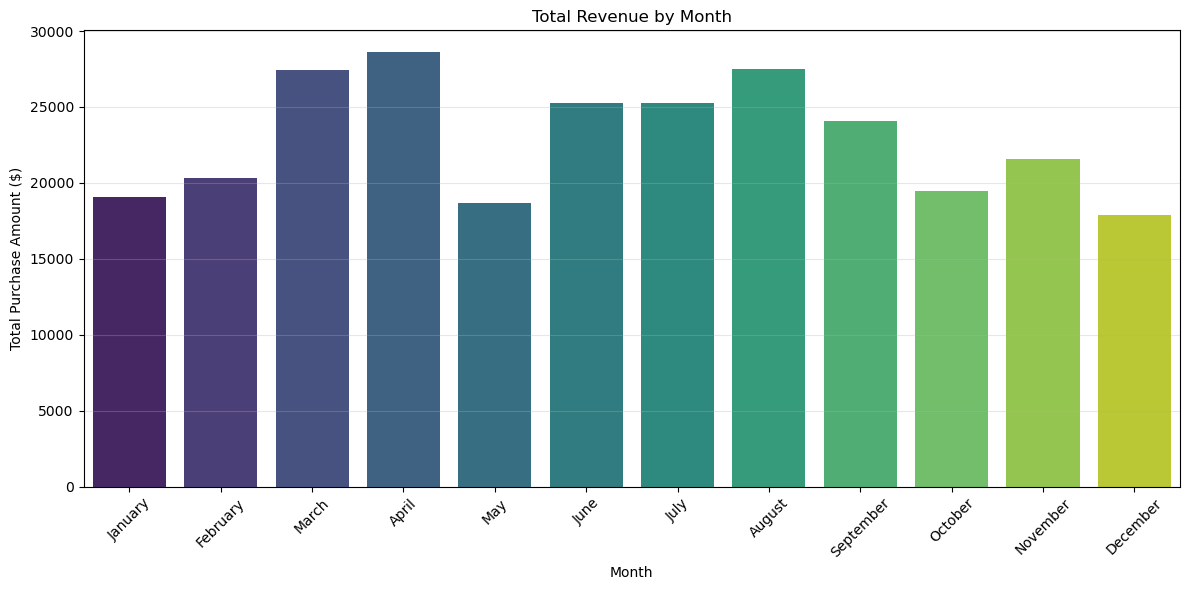

In [90]:
# Extract month information from Time_of_Purchase
df['Month'] = df['Time_of_Purchase'].dt.month
df['Month_Name'] = df['Time_of_Purchase'].dt.month_name()

# Aggregate total revenue by month
monthly_revenue = df.groupby(['Month', 'Month_Name'])['Purchase_Amount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('Month')  # Ensure chronological order

# Plot Total Revenue by month
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_revenue, x='Month_Name', y='Purchase_Amount', hue='Month_Name', palette='viridis')

# Formatting the plot
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The monthly revenue distribution indicates seasonal variation in purchasing behaviour, with certain months generating higher revenue than others. These patterns can inform promotional timing and inventory planning.

In [91]:
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
df['Month'] = df['Time_of_Purchase'].dt.month

monthly_revenue = df.groupby('Month')['Purchase_Amount'].sum()

monthly_counts = df['Month'].value_counts().sort_index()
monthly_counts

Month
1      75
2      68
3      93
4     100
5      76
6      89
7      94
8      98
9      84
10     79
11     80
12     64
Name: count, dtype: int64

In addition to revenue trends, the number of purchases per month follows a similar pattern, indicating that higher revenue months are driven by increased transaction volume rather than higher average order values alone.

## 4. Modelling & Machine Learning

The exploratory data analysis revealed clear patterns in customer behaviour, including differences in purchasing behaviour by intent, age group, channel, and geographic market. While EDA provides valuable descriptive insights, it does not allow for prediction or quantification of relationships between variables. 

In this section, machine learning techniques are applied to model customer behaviour and explore the predictive power of selected features. The goal is not only to build a production-level system, but also to demonstrate how data-driven models can support decision-making in a consumer analytics context.

## 5. Conclusions & Strategic Insights

* **Customer Demographics & Profiling**

The customer base is predominantly young to middle-aged, with an average age of 34.3 years and the majority falling within the 18–45 age range. No customers aged 55+ are present in the dataset, suggesting the platform primarily attracts younger consumers. Female customers represent 45.2% of the customer base and demonstrate the highest average spending per purchase ($282.09), followed closely by customers identifying as Other and Male customers.

Clear differences in category preferences emerge across age groups. Customers aged 18–25 show strong interest in Sports & Outdoors, Mobile Accessories, and Office Supplies, while those aged 26–35 favour Groceries, Animal Feed, and Food & Beverages. Customers aged 36–45 are more inclined toward Electronics, Jewellery & Accessories, and Packages, whereas the 46–55 group displays greater interest in Toys & Games and Beauty & Personal Care. Average spending is highest among the youngest age group and gradually declines with age.

Category preferences also vary by gender. Female customers dominate Jewellery & Accessories, Electronics, and Health Care, while Male customers show stronger preferences for Home Appliances, Gardening & Outdoors, and Software & Apps. Customers identifying as Other exhibit particularly strong engagement with Packages and Home Appliances. These differences support the feasibility of demographic-based product segmentation.

* **Purchasing Habits & Drivers**

The average purchase amount across customers ranges between approximately $274 and $282. All customers in the dataset are repeat buyers (purchase frequency >1), indicating either exceptionally strong retention or a dataset that focuses exclusively on repeat purchasers. Nearly half of customers (49.1%) are members of the loyalty programme, and 68.5% report high satisfaction levels (rating ≥4), suggesting generally positive customer experiences.

Purchase intent analysis reveals wide spending distributions across all intent types. Need-based and impulsive purchases exhibit the greatest variability and the highest outliers, indicating that both functional necessity and spontaneous decisions can lead to high-value transactions.

Discount usage is common across all genders (approximately 50–56%), with the highest usage observed among customers identifying as Other. However, no strong relationship between discount usage and customer satisfaction or spending was identified, suggesting that discounts alone may not significantly influence perceived value or long-term satisfaction.

* **Channels & Payment Preferences**

Device usage analysis highlights the importance of mobile platforms. Smartphone and tablet users display the highest levels of social media influence, particularly among younger age groups (18–35), reinforcing the importance of mobile-first design and social media–driven marketing strategies.

Payment behaviour shows clear preferences, with PayPal accounting for the highest number of transactions and total revenue. Credit cards generate the highest average revenue per transaction, while cash payments are associated with lower average purchase amounts. These findings suggest that encouraging digital payment methods may support higher-value transactions and smoother checkout experiences.

* **Geographic & Loyalty Insights**

Revenue is concentrated within a small number of countries, with the top ten markets accounting for a substantial proportion of total purchase value. When controlling for market size by using average brand loyalty scores, notable differences in customer loyalty emerge across these key markets. Some high-revenue countries also demonstrate strong average loyalty, while others appear more transaction-driven, highlighting opportunities for targeted retention strategies in specific regions.

Overall loyalty indicators are strong, with high repeat purchase rates and substantial loyalty programme participation. However, customers with lower purchase frequency, lower satisfaction scores, or lower loyalty scores may warrant closer monitoring as potential churn-risk segments.

* **Seasonal Patterns**

The purchasing activity by month reveals clear seasonal patterns. Both transaction volume and total revenue peak during spring and summer months, particularly in April and August, while December records the lowest activity levels. These trends suggest that promotional efforts and inventory planning may be most effective when aligned with periods of naturally higher demand.

* **Marketing Strategy**

Based on the analysis, the primary target segment consists of customers aged 18–35, particularly females using smartphones or tablets who are highly influenced by social media and frequently purchase categories such as Jewellery & Accessories, Electronics, and Groceries. This segment is well suited to mobile-optimised campaigns, personalised recommendations, and social media advertising.

Marketing effectiveness appears strongest on mobile devices and among younger demographics, supporting continued investment in mobile and social channels. From a geographic perspective, prioritising top-revenue countries for loyalty-building initiatives could strengthen long-term customer value. Encouraging the use of digital payment methods and timing promotional campaigns around peak seasonal periods may further enhance performance.

 END